<a href="https://colab.research.google.com/github/Faiq-danZ/worksafe-ai/blob/main/training/train_tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. MOUNT DRIVE

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path_processed = '/content/drive/MyDrive/Data/Data/Processed/'
path_model     = '/content/drive/MyDrive/Data/Models/'

import os
os.makedirs(path_model, exist_ok=True)
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


## 2. IMPORT LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## 3. LOAD DATASET

In [ ]:
df_train = pd.read_csv(path_processed + 'train_data.csv')
df_test  = pd.read_csv(path_processed + 'test_data.csv')

with open(path_processed + 'feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train['risk_label'].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test['risk_label'].values.astype(np.int32)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"Label  : {np.unique(y_train)}")

X_train: (715, 50)
X_test : (179, 50)
Label  : [0 1 2]


## 4. CLASS WEIGHT

In [ ]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.3095238095238095), 1: np.float64(0.7590233545647559), 2: np.float64(1.0882800608828007)}


## 5. CUSTOM LOSS: FOCAL LOSS

In [ ]:
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss - nangani class imbalance lebih baik dari CE biasa.
    Formula: FL = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss'):
        super().__init__(name=name)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true_oh = tf.cast(tf.one_hot(tf.cast(y_true, tf.int32), depth=3), tf.float32)
        y_pred    = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1 - 1e-7)

        ce           = -y_true_oh * tf.math.log(y_pred)
        p_t          = tf.reduce_sum(y_true_oh * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        loss         = self.alpha * focal_weight * tf.reduce_sum(ce, axis=-1)
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg

# Cek
_fl = FocalLoss()
_yt = tf.constant([0, 1, 2], dtype=tf.float32)
_yp = tf.constant([[0.7, 0.2, 0.1], [0.1, 0.8, 0.1], [0.1, 0.2, 0.7]])
print(f"Focal Loss test: {_fl(_yt, _yp).numpy():.4f} — OK")

Focal Loss test: 0.0057 — OK


## 6. BUILD MODEL (FUNCTIONAL API)

In [ ]:
def build_model(input_dim, n_classes=3, dropout=0.3):
    inputs = keras.Input(shape=(input_dim,), name='input')

    # Block 1
    x = layers.Dense(256, name='d1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout, name='drop1')(x)

    # Block 2
    x = layers.Dense(128, name='d2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout, name='drop2')(x)

    # Skip connection
    skip = layers.Dense(64, name='skip')(inputs)

    # Block 3
    x = layers.Dense(64, name='d3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu')(x)
    x = layers.Add(name='residual')([x, skip])
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout / 2)(x)

    # Output
    x       = layers.Dense(32, activation='relu', name='d4')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    return Model(inputs, outputs, name='WorkSafe_Tabular_v1')

model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "WorkSafe_Tabular_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 50)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d1 (Dense)          │ (None, 256)       │     13,056 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 256)       │      1,024 │ d1[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256)       │          0 │ bn1[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 256)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d2 (Dense)          │ (None, 128)       │     32,896 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2                 │ (None, 128)       │        512 │ d2[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ bn2[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 128)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d3 (Dense)          │ (None, 64)        │      8,256 │ drop2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn3                 │ (None, 64)        │        256 │ d3[0][0]          │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ bn3[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip (Dense)        │ (None, 64)        │      3,264 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 64)        │          0 │ activation_2[0][… │
│                     │                   │            │ skip[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64)        │          0 │ residual[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ d4 (Dense)          │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         99 │ d4[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 61,443 (240.01 KB)

 Trainable params: 60,547 (236.51 KB)

 Non-trainable params: 896 (3.50 KB)

## 7. COMPILE

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=FocalLoss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print("Model compiled.")

Model compiled.


## 8. CALLBACKS

In [ ]:
checkpoint_path = path_model + 'best_model.keras'

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),

    ModelCheckpoint(filepath=checkpoint_path, monitor='val_accuracy',
                    save_best_only=True, verbose=1),

    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]
print("Callbacks siap.")

Callbacks siap.


## 9. TRAINING

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)
print(f"\nBest val_accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/100
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5812 - loss: 0.7558
Epoch 1: val_accuracy improved from None to 0.77622, saving model to /content/drive/MyDrive/Data/Models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Data/Models/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6294 - loss: 0.6467 - val_accuracy: 0.7762 - val_loss: 0.4785 - learning_rate: 0.0010
Epoch 2/100
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8114 - loss: 0.4174 
Epoch 2: val_accuracy improved from 0.77622 to 0.79720, saving model to /content/drive/MyDrive/Data/Models/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Data/Models/best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8147 - loss: 0.3955 - val_accuracy: 0.7972 - val_loss: 0.4037 - learning_rate: 0.0010
Epoch 3/100
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8001 - loss: 0.3279 
Epoch 3: val_accuracy improved from 0.79720 

## 10. EVALUASI TEST SET

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}")

Test Loss     : 0.1521
Test Accuracy : 0.9609


## 11. CLASSIFICATION REPORT

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=['Low Risk', 'Medium Risk', 'High Risk']
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step
              precision    recall  f1-score   support

    Low Risk       0.92      0.98      0.95        45
 Medium Risk       0.99      0.92      0.95        79
   High Risk       0.96      1.00      0.98        55

    accuracy                           0.96       179
   macro avg       0.96      0.97      0.96       179
weighted avg       0.96      0.96      0.96       179



## 12. CONFUSION MATRIX

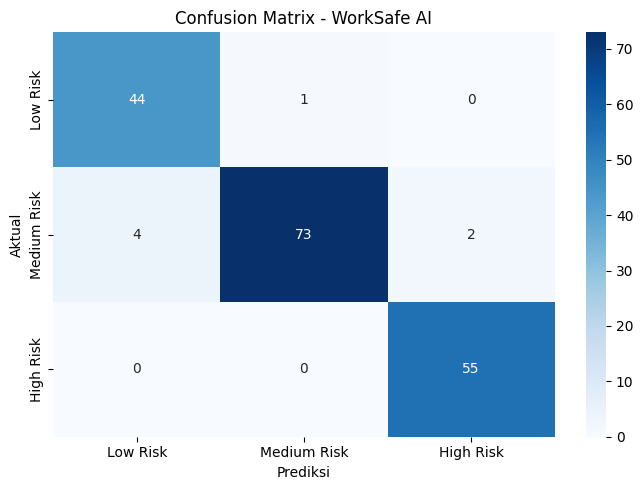

In [ ]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Low Risk', 'Medium Risk', 'High Risk']

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - WorkSafe AI')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig(path_model + 'confusion_matrix.png', dpi=100)
plt.show()

## 13. TRAINING HISTORY PLOT

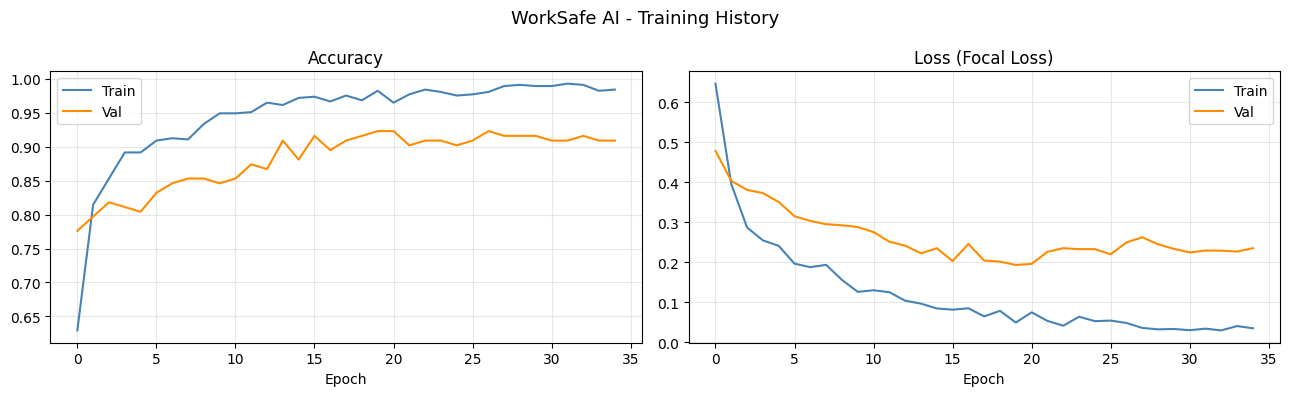

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='darkorange')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='darkorange')
axes[1].set_title('Loss (Focal Loss)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('WorkSafe AI - Training History', fontsize=13)
plt.tight_layout()
plt.savefig(path_model + 'training_history.png', dpi=100)
plt.show()

## 14. SIMPAN MODEL

In [ ]:
model_path = path_model + 'worksafe_model_v1.keras'
model.save(model_path)
print(f"Model disimpan: {model_path}")

# Verifikasi load
loaded = keras.models.load_model(model_path, custom_objects={'FocalLoss': FocalLoss})
loss_v, acc_v = loaded.evaluate(X_test, y_test, verbose=0)
print(f"Verifikasi accuracy: {acc_v:.4f} – OK")

Model disimpan: /content/drive/MyDrive/Data/Models/worksafe_model_v1.keras
Verifikasi accuracy: 0.9609 – OK


## 15. COPY SCALER & FEATURE LIST KE FOLDER MODEL

In [ ]:
import shutil

shutil.copy(path_processed + 'scaler.pkl',      path_model + 'scaler.pkl')
shutil.copy(path_processed + 'imputer.pkl',     path_model + 'imputer.pkl')
shutil.copy(path_processed + 'feature_cols.pkl', path_model + 'feature_cols.pkl')

print("File tersimpan di folder model:")
print("  worksafe_model_v1.keras")
print("  scaler.pkl")
print("  imputer.pkl")
print("  feature_cols.pkl")

File tersimpan di folder model:
  worksafe_model_v1.keras
  scaler.pkl
  imputer.pkl
  feature_cols.pkl
